# The funnel pipeline — conversations → pages → conversion model

**Mission.** From a parquet of ChatGPT shopping conversations (each turn:
question, answer, the links the answer surfaced, direct clicks on them, and
the next 10 pages browsed), build a **predictive funnel model**: measure the
**conversion rate** of these journeys and the **weight of agent
recommendations** — the brands the agent names, the links it shows — in the
user's decision to buy. (Context: LLM referrals to e-commerce are now a
measurable channel — Kaiser & Schulze 2026 — and LLM steering can nearly
triple sponsored selection — Salvi et al. 2026. See
[`docs/STATE_OF_THE_ART.md`](../docs/STATE_OF_THE_ART.md).)

Three modules, each writing parquet with pinned schemas
([`docs/DATA_DICTIONARY.md`](../docs/DATA_DICTIONARY.md)):

| module | what it does | outputs |
|---|---|---|
| 1 · `conveyer.conversations` | intent, sentiment, topics, **brand mentions** (unsolicited = the exposure), funnel stages (keywords + HMM) | `turn_features`, `conversation_features` |
| 2 · `conveyer.scraping` | classify every surfaced/visited URL (page → base-URL fallback → URL/domain heuristics), extract & match products | `scraped_pages`, `scraped_products` |
| 3 · `conveyer.journey` | behavioural events, conversion (documented proxy) with credible intervals, funnel transitions, the logistic model | `funnel_events`, `journey_features`, `funnel_transitions`, `model_coefficients` |

Everything below runs **offline** on a synthetic dataset *with ground truth*
when `data/conversations.parquet` is absent — and the run scores itself
against that truth at the end. Real data slots in without code changes.

## 0 · Setup

In [1]:
import shutil, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "conveyer").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from conveyer import run_pipeline
from conveyer.conversations import ConversationConfig
from conveyer.journey import JourneyConfig
from conveyer.scraping import ScrapeConfig

OUT = ROOT / "outputs" / "demo"
shutil.rmtree(OUT, ignore_errors=True)     # fresh, deterministic demo run

HUE, HUE2, INK = "#4878a8", "#c17a3f", "#444444"
pd.set_option("display.max_colwidth", 56)

def barh(ax, counts, title, hue=HUE):
    counts = counts.sort_values()
    ax.barh([str(i) for i in counts.index], counts.values, color=hue, height=0.62)
    for y, v in enumerate(counts.values):
        ax.text(v + max(counts.values) * 0.02, y, f"{v:g}", va="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.tick_params(labelsize=9, colors=INK, length=0)
    ax.set_xlim(0, max(counts.values) * 1.18)
    for s in ("top", "right", "left", "bottom"):
        ax.spines[s].set_visible(False)
    ax.xaxis.set_visible(False)

## 1 · Run everything

One call chains the three modules. On real data, pass
`ScrapeConfig(offline=False)` for polite online scraping (robots.txt,
per-domain rate limits, per-URL wall-clock caps, JSONL checkpointing + resume
— nothing can hang, nothing is lost on interrupt).

In [2]:
art = run_pipeline(
    ConversationConfig(data_path=str(ROOT / "data/conversations.parquet"),
                       synthetic_n_sessions=40, out_dir=str(OUT / "conversations")),
    ScrapeConfig(offline=True, out_dir=str(OUT / "scrape"), progress_every=0),
    JourneyConfig(conversion_stage="cart", out_dir=str(OUT / "journey")),
)
turns = art["conversations"]["turns_out"]
convs = art["conversations"]["conversations"]
pages = art["scrape"]["pages"]
events = art["journey"]["events"]
features = art["journey"]["features"]

[conversations] SYNTHETIC (40 sessions, 97 turns) | turns=97 | sessions=40


[conversations] sentiment=lexicon | topics=kmeans | reco_rate=70.1%
[export] /home/user/conveyer/outputs/demo/conversations/turn_features.parquet (97) | /home/user/conveyer/outputs/demo/conversations/conversation_features.parquet (40)
[sources] conversation link columns | urls=74 | turns_with_mentions=97
[fetch] mode=offline | pending=74 | workers=12 | per-url cap=30s | line-by-line -> /home/user/conveyer/outputs/demo/scrape/scraped_pages.jsonl
[model] no model at outputs/page_model.npz — training on the synthetic ground truth (once)…


[model] trained on 495 samples, 15 subtypes (train acc 0.899) -> outputs/page_model.npz


[export] /home/user/conveyer/outputs/demo/scrape/scraped_pages.parquet (74 pages) | /home/user/conveyer/outputs/demo/scrape/scraped_products.parquet (66 products) | new this run: 74
[categories]
page_category
shopping     28
community    16
editorial    12
unrelated    12
search        4
reference     2
[match] products=66 | coincide=0
[validate] all labels consistent with the URL rules


[journey] events=233 | sessions=40 | conversions=14 (35.0% @ cart) | lift={'followed_recommendation': 2.5, 'followed_agent_link': 2.5, 'visited_recommended_brand': 2.2}
[journey] full-model AUC train=1.000 test=0.969 | exposure-model weights (no mediators):
   model                   feature  coef_standardized  odds_ratio_per_sd
exposure       followed_agent_link             1.0482             2.8526
exposure                   n_turns             0.9473             2.5787
exposure     mean_answer_sentiment             0.7441             2.1046
exposure asks_recommendation_share             0.4738             1.6060
exposure visited_recommended_brand            -0.3471             0.7067
[export] /home/user/conveyer/outputs/demo/journey/: funnel_events, journey_features, funnel_transitions, model_coefficients
[pipeline eval vs ground truth] {'n': 40.0, 'conversion_accuracy': 1.0, 'followed_accuracy': 1.0}


## 2 · Module 1 — what was said

Turn-level intent, sentiment, brand mentions and funnel stages;
session-level aggregates including the HMM-smoothed **journey path**.
`brands_unsolicited` — brands the agent introduced that the user never asked
about — is the recommendation exposure the funnel model weighs.

In [3]:
turns[["session_id", "question", "intent", "funnel_stage", "journey_stage",
       "question_sentiment", "brands_a", "brands_unsolicited", "n_links_cited"]].head(8)

,session_id,question,intent,funnel_stage,journey_stage,question_sentiment,brands_a,brands_unsolicited,n_links_cited
0,s0000,what is moisturizer and how does it work?,informational,Awareness,Awareness,0.0,[CeraVe],[CeraVe],0
1,s0000,CeraVe vs Paula's Choice — which is better for dry s...,comparison,Evaluation,Evaluation,-1.0,[CeraVe],[],0
2,s0000,how much is it and is it in stock?,informational,Intent,Intent,0.0,[CeraVe],[CeraVe],2
3,s0001,what should i use for acne?,purchase,Discovery,Discovery,0.0,[The Ordinary],[The Ordinary],0
4,s0001,cheapest place to get it?,informational,Intent,Intent,0.0,[The Ordinary],[The Ordinary],2
5,s0002,why do i have dark spots?,informational,Awareness,Awareness,0.0,[La Roche-Posay],[La Roche-Posay],0
6,s0002,where can i buy La Roche-Posay Anthelios SPF 60 Suns...,purchase,Intent,Intent,0.0,[La Roche-Posay],[],2
7,s0003,what is exfoliant and how does it work?,informational,Awareness,Awareness,0.0,[Paula's Choice],[Paula's Choice],0


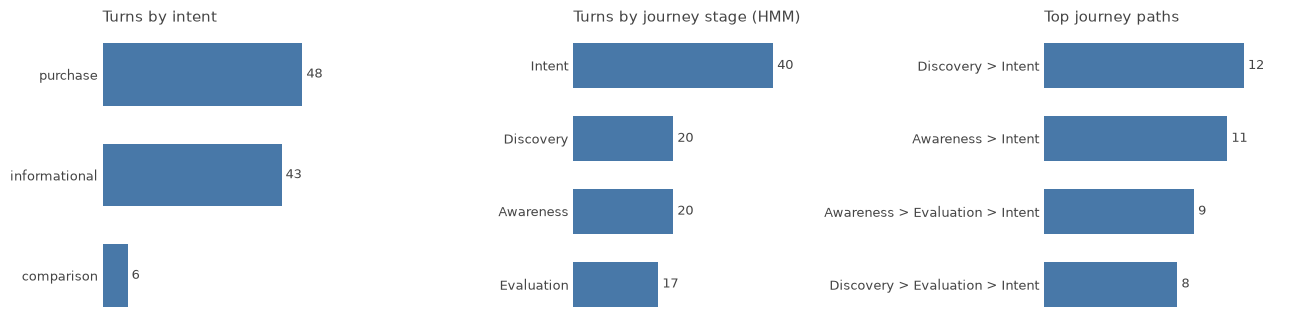

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
barh(axes[0], turns["intent"].value_counts(), "Turns by intent")
barh(axes[1], turns["journey_stage"].value_counts(), "Turns by journey stage (HMM)")
barh(axes[2], convs["journey_path"].value_counts().head(6), "Top journey paths")
plt.tight_layout(); plt.show()

### 2.1 How the agent responds to similar prompts

Grouping turns by **intent** (and by HMM journey stage) shows the agent's
behaviour under similar prompts: how often it volunteers a recommendation
(`reco_rate` = share of turns with an *unsolicited* brand), how positive its
answers read, and how many links it surfaces. This is the supply side of the
funnel — what the agent injects, before the user does anything with it.

In [5]:
def _n(x):
    return len(x) if hasattr(x, "__len__") and not isinstance(x, str) else 0

t = turns.assign(recommends=turns["brands_unsolicited"].map(_n) > 0,
                 n_brands=turns["brands_a"].map(_n))
by_intent = (t.groupby("intent")
             .agg(turns=("message_id", "count"),
                  reco_rate=("recommends", "mean"),
                  answer_sentiment=("answer_sentiment", "mean"),
                  brands_per_answer=("n_brands", "mean"),
                  links_cited=("n_links_cited", "mean"))
             .round(2).sort_values("reco_rate", ascending=False))
display(by_intent)
by_stage = (t.groupby("journey_stage")
            .agg(turns=("message_id", "count"), reco_rate=("recommends", "mean"),
                 answer_sentiment=("answer_sentiment", "mean"),
                 links_cited=("n_links_cited", "mean"))
            .round(2).sort_values("reco_rate", ascending=False))
by_stage

,turns,reco_rate,answer_sentiment,brands_per_answer,links_cited
intent,,,,,
informational,43,0.86,0.60,1.0,0.79
purchase,48,0.65,0.82,1.0,0.96
comparison,6,0.00,0.78,1.0,0.00


,turns,reco_rate,answer_sentiment,links_cited
journey_stage,,,,
Awareness,20,1.0,0.68,0.0
Discovery,20,1.0,0.87,0.0
Intent,40,0.7,0.68,2.0
Evaluation,17,0.0,0.69,0.0


## 3 · Module 2 — where the user landed

Every URL from `a_links_source` / `ai_click` / `next_10_urls`, classified by
**eight independent evidence channels** — URL tokens, service routing
(`docs.google.com` is a tool, never "search"), curated domain lists, page
markup, the vendor prior, the offline domain directory, the hosting-platform
fingerprint (a bot-walled Shopify store still reads as a storefront) and a
**self-trained model** (`python -m conveyer.scraping.model train`). The
**fallback chain** means nothing stays unclassified: page content when
fetchable → the **base URL's** content when not → URL + domain heuristics
alone (an unfetchable `amazon.com/gp/cart/…` is still
`shopping · cart · retailer · Purchase`). Deep dive + classifier behaviour
analysis: [`02_page_classifier.ipynb`](02_page_classifier.ipynb).

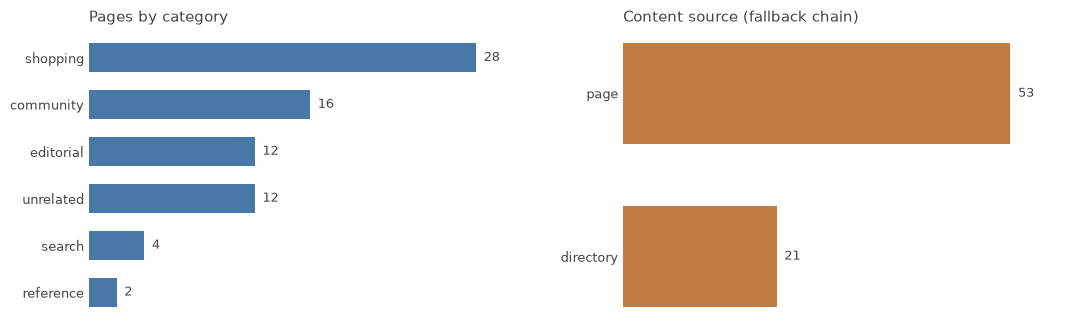

,url,page_category,page_subtype,seller_type,funnel_stage,chat_match_strength,classification_signals
19,https://www.nytimes.com/best-moisturizers-for-dry-skin,editorial,article,na,Evaluation,likely,"[url, domain, markup, model]"
55,https://www.amazon.com/products/gaming-laptop-18,unrelated,pdp,retailer,Irrelevant,none,"[url, domain, markup, model]"
10,https://www.target.com/checkout,shopping,checkout,retailer,Purchase,none,"[url, domain, model, domain_profile, directory_content]"
70,https://www.nytimes.com/best-exfoliants-for-dry-skin,editorial,article,na,Evaluation,likely,"[url, domain, markup, model]"
54,https://x.com/somebody/status/2000000017,community,forum,na,Evaluation,none,"[domain, directory_content]"
26,https://www.ulta.com/cart,shopping,cart,retailer,Purchase,none,"[url, domain, model, directory_content]"


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
barh(axes[0], pages["page_category"].value_counts(), "Pages by category")
barh(axes[1], pages["fetch_scope"].value_counts(), "Content source (fallback chain)", hue=HUE2)
plt.tight_layout(); plt.show()
pages[["url", "page_category", "page_subtype", "seller_type", "funnel_stage",
       "chat_match_strength", "classification_signals"]].sample(6, random_state=1)

### 3.1 Which links get the attention

Link relevancy from behaviour, three reads: **dwell** (time until the next
request in the trail — an upper bound on attention), **trail position** (how
early after the answer the page was opened) and the **page↔chat connection**
(`chat_match_strength`: does this page carry the very product the agent
mentioned?). The interesting cross-read: do pages matching the agent's
recommendation hold attention longer than unmatched ones?

In [7]:
trail = pages[pages["mean_dwell_seconds"].notna()]
by_cat = (trail.groupby("page_category")
          .agg(pages=("url", "count"), mean_dwell_s=("mean_dwell_seconds", "mean"),
               mean_position=("mean_trail_position", "mean"),
               relevant_share=("is_study_relevant", "mean"))
          .round(2).sort_values("mean_dwell_s", ascending=False))
display(by_cat)

by_match = (trail.groupby(trail["chat_match_strength"].replace("", "none"))
            .agg(pages=("url", "count"), mean_dwell_s=("mean_dwell_seconds", "mean"),
                 total_dwell_s=("total_dwell_seconds", "sum"),
                 visits=("times_visited", "sum")).round(2))
display(by_match)

top = trail.sort_values("total_dwell_seconds", ascending=False)
top[["url", "page_category", "funnel_stage", "chat_match_strength",
     "times_visited", "total_dwell_seconds", "mean_trail_position"]].head(8)

,pages,mean_dwell_s,mean_position,relevant_share
page_category,,,,
editorial,9,28.48,2.53,1.0
search,4,23.04,1.00,1.0
shopping,25,21.89,2.07,1.0
community,6,21.52,2.03,0.5
reference,2,20.88,1.00,1.0
unrelated,12,14.08,1.00,0.0


,pages,mean_dwell_s,total_dwell_s,visits
chat_match_strength,,,,
likely,23,22.96,840.34,66
none,35,20.22,1264.51,63


,url,page_category,funnel_stage,chat_match_strength,times_visited,total_dwell_seconds,mean_trail_position
2,https://x.com/,community,Evaluation,none,12,279.085,2.167
12,https://www.target.com/cart,shopping,Purchase,none,7,177.867,2.714
5,https://www.neutrogena.com/products/neutrogena-hydro...,shopping,Intent,likely,4,136.027,2.250
22,https://www.sephora.com/cart,shopping,Purchase,none,3,131.000,3.333
4,https://www.sephora.com/products/drunk-elephant-prot...,shopping,Intent,likely,5,70.612,1.000
34,https://www.byrdie.com/best-serums-for-dry-skin,editorial,Evaluation,likely,2,66.716,2.500
42,https://www.ulta.com/products/drunk-elephant-protini...,shopping,Intent,none,1,57.129,2.000
3,https://www.target.com/products/the-inkey-list-hyalu...,shopping,Intent,likely,6,55.301,1.000


## 4 · Module 3 — did it move the needle

### 4.1 The event table

Conversation ↔ behaviour linkage at event grain: `cited` (exposure),
`ai_click`, `trail_visit` (with dwell). `brand_match` ties each visited page's
brand back to the chat (`unsolicited_rec` = the agent introduced it);
`commerce_depth` reads 1 = shop, 2 = cart, 3 = checkout.

In [8]:
events[["session_id", "event_type", "url", "page_category", "page_brand",
        "brand_match", "followed_agent_link", "commerce_depth", "dwell_seconds"]].head(10)

,session_id,event_type,url,page_category,page_brand,brand_match,followed_agent_link,commerce_depth,dwell_seconds
0,s0000,cited,https://www.amazon.com/products/cerave-moisturizing-...,shopping,CeraVe,unsolicited_rec,False,1,NaN
1,s0000,cited,https://www.cerave.com/products/cerave-moisturizing-...,shopping,CeraVe,unsolicited_rec,False,1,NaN
2,s0000,trail_visit,https://www.amazon.com/products/gaming-laptop-0,unrelated,TechCo,none,False,0,3.664
3,s0000,trail_visit,https://x.com/,community,,none,False,0,41.874
4,s0000,trail_visit,https://x.com/somebody/status/2000000000,community,,none,False,0,NaN
5,s0001,cited,https://www.sephora.com/products/the-ordinary-niacin...,shopping,The Ordinary,unsolicited_rec,False,1,NaN
6,s0001,cited,https://www.theordinary.com/products/the-ordinary-ni...,shopping,The Ordinary,unsolicited_rec,False,1,NaN
7,s0001,ai_click,https://www.sephora.com/products/the-ordinary-niacin...,shopping,The Ordinary,unsolicited_rec,True,1,NaN
8,s0001,trail_visit,https://www.sephora.com/products/the-ordinary-niacin...,shopping,The Ordinary,unsolicited_rec,True,1,30.300
9,s0001,trail_visit,https://www.allure.com/best-serums-for-dry-skin,editorial,The Inkey List,none,False,0,1.564


### 4.2 Conversion by exposure — with credible intervals

`converted` = reached **cart or deeper** in the post-turn trail (an explicit
proxy — no purchase confirmation exists in this schema; switch depth with
`JourneyConfig.conversion_stage`). Jeffreys 95% intervals; `lift` =
rate(exposed) / rate(unexposed).

In [9]:
report = art["journey"]["report"]
print("lift:", report.attrs["lift"])
report

lift: {'followed_recommendation': 2.5, 'followed_agent_link': 2.5, 'visited_recommended_brand': 2.2}


,stratum,n,conversions,rate,ci_low,ci_high
0,overall,40,14,0.3500,0.2167,0.5041
1,followed_recommendation=True,20,10,0.5000,0.2934,0.7066
2,followed_recommendation=False,20,4,0.2000,0.0715,0.4082
3,followed_agent_link=True,20,10,0.5000,0.2934,0.7066
4,followed_agent_link=False,20,4,0.2000,0.0715,0.4082
5,visited_recommended_brand=True,18,9,0.5000,0.2836,0.7164
6,visited_recommended_brand=False,22,5,0.2273,0.0924,0.4286


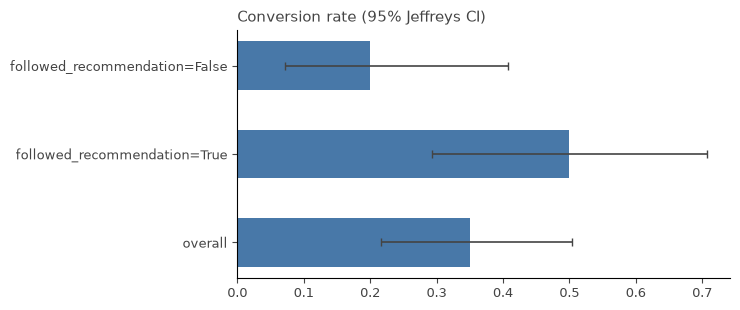

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
sub = report[report["stratum"].str.contains("overall|followed_recommendation")]
ys = np.arange(len(sub))
ax.barh(ys, sub["rate"], color=HUE, height=0.55)
ax.errorbar(sub["rate"], ys, xerr=[sub["rate"] - sub["ci_low"], sub["ci_high"] - sub["rate"]],
            fmt="none", ecolor=INK, elinewidth=1.2, capsize=3)
ax.set_yticks(ys, sub["stratum"], fontsize=9)
ax.set_title("Conversion rate (95% Jeffreys CI)", fontsize=11, color=INK, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK, labelsize=9)
plt.tight_layout(); plt.show()

### 4.3 Funnel transitions

The journey as a stage sequence: HMM-smoothed conversation stages, then the
visited pages' stages in trail order.

In [11]:
tr = art["journey"]["transitions"]
tr.pivot_table(index="from_stage", columns="to_stage", values="prob").fillna(0).round(2)

to_stage,Awareness,Evaluation,Intent,Purchase
from_stage,,,,
Awareness,0.00,0.54,0.46,0.00
Discovery,0.00,0.40,0.60,0.00
Evaluation,0.00,0.37,0.42,0.21
Intent,0.05,0.38,0.47,0.10
Purchase,0.00,0.20,0.07,0.73


### 4.4 The predictive models — weight of agent recommendations

Two logistic models on standardized features, holdout-validated:

* the **exposure model** (charted) contains conversation features + the
  exposure flags and **no post-treatment mediators** — visit counts and dwell
  are *consequences* of following a recommendation, and controlling for them
  would absorb the very effect we want to read. Its `followed_agent_link` /
  `visited_recommended_brand` rows are the headline recommendation weight;
* the **full model** adds the behavioural features back for maximum
  predictive power — use it to predict, not to interpret exposure.

**Association, not causation** either way — users self-select into following
recommendations; see [`docs/FUNNEL_MODEL.md`](../docs/FUNNEL_MODEL.md) §5.

exposure model AUC test=0.562 | full model AUC test=0.969 (n=28/12)


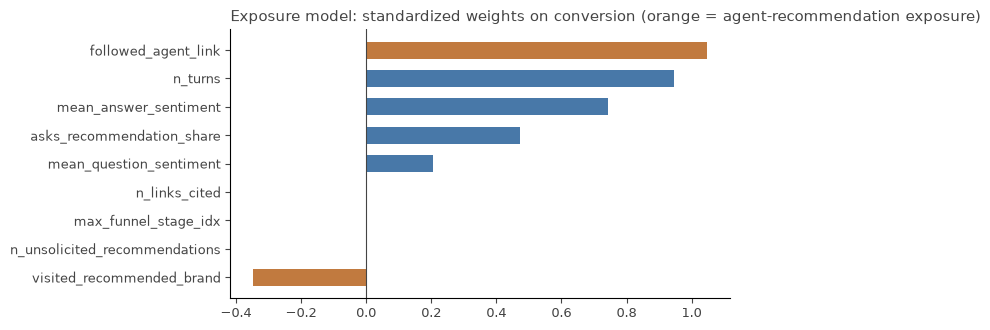

,model,feature,coef_standardized,odds_ratio_per_sd
0,exposure,followed_agent_link,1.0482,2.8526
1,exposure,n_turns,0.9473,2.5787
2,exposure,mean_answer_sentiment,0.7441,2.1046
3,exposure,asks_recommendation_share,0.4738,1.6060
4,exposure,visited_recommended_brand,-0.3471,0.7067
5,exposure,mean_question_sentiment,0.2046,1.2271
6,exposure,n_unsolicited_recommendations,0.0000,1.0000
7,exposure,max_funnel_stage_idx,0.0000,1.0000
8,exposure,n_links_cited,0.0000,1.0000
9,full,n_visits,1.7424,5.7113


In [12]:
model = art["journey"]["model"]
exp_m, full_m = model["exposure"], model["full"]
print(f"exposure model AUC test={exp_m['auc_test']:.3f} | "
      f"full model AUC test={full_m['auc_test']:.3f} "
      f"(n={model['n_train']}/{model['n_test']})")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
c = exp_m["coefficients"].sort_values("coef_standardized")
colors = [HUE2 if f in ("followed_agent_link", "visited_recommended_brand") else HUE
          for f in c["feature"]]
ax.barh(c["feature"], c["coef_standardized"], color=colors, height=0.6)
ax.axvline(0, color=INK, lw=0.8)
ax.set_title("Exposure model: standardized weights on conversion "
             "(orange = agent-recommendation exposure)",
             fontsize=10.5, color=INK, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK, labelsize=9)
plt.tight_layout(); plt.show()
model["coefficients"]        # both models, long form (also written to parquet)

### 4.5 When is a client susceptible to the agent's recommendation?

The lift of `followed_recommendation` recomputed **within segments** of the
conversation: who converts more when they follow the agent, relative to peers
in the same segment who didn't? Segments come from module 1's conversation
features — did the user *ask* for recommendations, how positive the exchange
read, how long the conversation ran, how deep the stated funnel stage went.
High lift + high follow-rate = the moments the agent's word carries the most
weight. (Observational, synthetic-validated — on real data these cells
produce the real profile. CIs on small segments are wide; read direction,
not decimals.)

,segment,sessions,follow_rate,conv_followed,conv_not_followed,lift
0,asks for recommendations (high),15,0.47,0.71,0.38,1.90
1,asks for recommendations (low),25,0.52,0.38,0.08,4.62
2,neutral/negative answer sentiment,40,0.50,0.50,0.20,2.50
3,long conversations,17,0.47,0.62,0.33,1.88
4,short conversations,23,0.52,0.42,0.09,4.58
5,reached Intent+ in conversation,40,0.50,0.50,0.20,2.50


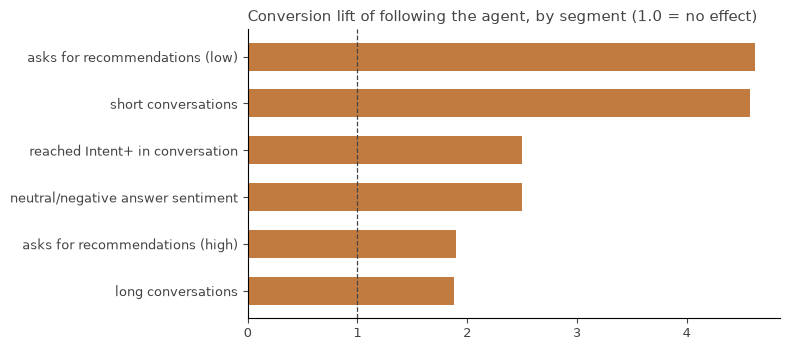

In [13]:
f = features.copy()
segs = []
def seg(mask, name):
    g = f[mask]
    fol, not_ = g[g["followed_recommendation"]], g[~g["followed_recommendation"]]
    if len(g) < 4 or not len(fol) or not len(not_):
        return
    a, b = fol["converted"].mean(), not_["converted"].mean()
    segs.append({"segment": name, "sessions": len(g),
                 "follow_rate": round(len(fol) / len(g), 2),
                 "conv_followed": round(a, 2), "conv_not_followed": round(b, 2),
                 "lift": round(a / b, 2) if b > 0 else np.inf})

med_ask = f["asks_recommendation_share"].median()
med_sent = f["mean_answer_sentiment"].median()
med_turns = f["n_turns"].median()
seg(f["asks_recommendation_share"] > med_ask,  "asks for recommendations (high)")
seg(f["asks_recommendation_share"] <= med_ask, "asks for recommendations (low)")
seg(f["mean_answer_sentiment"] > med_sent,     "positive answer sentiment")
seg(f["mean_answer_sentiment"] <= med_sent,    "neutral/negative answer sentiment")
seg(f["n_turns"] > med_turns,                  "long conversations")
seg(f["n_turns"] <= med_turns,                 "short conversations")
seg(f["max_funnel_stage_idx"] >= 3,            "reached Intent+ in conversation")
seg(f["max_funnel_stage_idx"] < 3,             "stayed Awareness/Evaluation")
seg(f["visited_recommended_brand"],            "visited a recommended brand")
susceptibility = pd.DataFrame(segs)
display(susceptibility)

fig, ax = plt.subplots(figsize=(8, 3.6))
s = susceptibility.replace(np.inf, np.nan).dropna(subset=["lift"]).sort_values("lift")
ax.barh(s["segment"], s["lift"], color=HUE2, height=0.6)
ax.axvline(1.0, color=INK, lw=0.9, ls="--")
ax.set_title("Conversion lift of following the agent, by segment (1.0 = no effect)",
             fontsize=10.5, color=INK, loc="left")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.tick_params(colors=INK, labelsize=9)
plt.tight_layout(); plt.show()

## 5 · Validation against ground truth

The synthetic generator plants session archetypes (converter-via-rec,
browser-via-rec, organic converter, no-follow, researcher), so the run can
score its own measurement grammar: did the conversion proxy and the exposure
detection recover the truth?

In [14]:
print(art["evaluation"])
gt = art["conversations"]["ground_truth"]
f = features.merge(gt, on="session_id")
f.groupby("gt_archetype")[["followed_recommendation", "converted"]].mean().round(2)

{'n': 40.0, 'conversion_accuracy': 1.0, 'followed_accuracy': 1.0}


,followed_recommendation,converted
gt_archetype,,
browser_via_rec,1.0,0.0
converter_via_rec,1.0,1.0
no_follow,0.0,0.0
organic_converter,0.0,1.0
researcher,0.0,0.0


## 6 · The artefacts

Eight parquet tables, every schema pinned and documented in
[`docs/DATA_DICTIONARY.md`](../docs/DATA_DICTIONARY.md):

In [15]:
for sub in ("conversations", "scrape", "journey"):
    for p in sorted((OUT / sub).glob("*.parquet")):
        t = pd.read_parquet(p)
        print(f"{sub:14} {p.name:32} {len(t):>5} rows x {t.shape[1]:>2} cols")

conversations  conversation_features.parquet       40 rows x 22 cols
conversations  turn_features.parquet               97 rows x 26 cols
scrape         scraped_pages.parquet               74 rows x 62 cols
scrape         scraped_products.parquet            66 rows x 28 cols
journey        funnel_events.parquet              233 rows x 16 cols
journey        funnel_transitions.parquet          14 rows x  4 cols
journey        journey_features.parquet            40 rows x 21 cols
journey        model_coefficients.parquet          21 rows x  4 cols


## 7 · Running on the real parquet

```bash
python -m conveyer.pipeline --data data/conversations.parquet --online
```

What changes: module 2 fetches for real (politely: robots.txt, per-domain
rate limiting that never blocks other domains, a hard wall-clock cap per URL,
line-by-line JSONL persistence with resume — a 265k-URL run can be
interrupted and continued at will). What to watch: the limitations in
[`docs/FUNNEL_MODEL.md`](../docs/FUNNEL_MODEL.md) — proxy outcome, 10-event
window, observational exposure, brand-lexicon coverage
(`conveyer/brands.py` is the single place to extend).